# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [21]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [22]:
corpus = """
romeo and juliet belonged to two rival families in the city of verona
their parents carried a long history of conflict anger and misunderstanding
during a grand celebration romeo first saw juliet and admired her beauty
juliet was kind intelligent graceful and respected by many people around her
they spoke together shared thoughts and quickly developed deep affection
despite the feud between their households they continued meeting secretly
romeo often dreamed about a peaceful future without hatred or violence
juliet believed that love could overcome division prejudice and fear
their friendship grew stronger through trust patience honesty and courage
a wise friar agreed to help the young couple pursue happiness
he hoped their marriage would finally bring unity between both families
romeo and juliet exchanged promises beneath the quiet evening sky
birds sang softly while gentle winds moved through nearby gardens
the ceremony was simple meaningful emotional and filled with optimism
however unexpected events soon changed the direction of their story
a dispute in the marketplace created tension among several citizens
hot tempers reckless actions and unfortunate choices led to tragedy
romeo faced difficult decisions involving loyalty responsibility and honor
juliet struggled with confusion sadness uncertainty and emotional pressure
messages failed to arrive at the correct destination in time
important information was delayed because of circumstances beyond control
friends attempted to offer guidance support comfort and encouragement
yet misunderstandings continued growing throughout the challenging situation
romeo believed juliet had passed away and felt overwhelming grief
his judgment was affected by despair sorrow heartbreak and desperation
juliet later awakened and discovered the consequences of the mistake
their tragic fate shocked relatives neighbors leaders and communities
the loss inspired reflection compassion forgiveness and reconciliation
both families finally recognized the cost of endless rivalry
they chose cooperation respect understanding and peace instead of conflict
the story became famous across generations cultures schools and literature
readers remember themes of devotion sacrifice destiny and human emotion
the narrative explores relationships communication choices and consequences
it demonstrates how wisdom empathy and dialogue prevent unnecessary suffering
romeo and juliet remain symbols of enduring love and commitment
their journey continues inspiring artists writers students and audiences worldwide
"""
print("corpus loaded sucessfully!")

corpus loaded sucessfully!


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [23]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]


print("Maximum sequence length:", max_len)
print("Total training sequences:", len(input_sequences))
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 261
Maximum sequence length: 13
Total training sequences: 323
X shape: (323, 12)
y shape: (323,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [24]:
rnn_model = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.build(input_shape=(None, max_len - 1))

# Model Summary
rnn_model.summary()

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train Model
rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)

print("Vanilla RNN — training complete")
print(f"Final Loss: {rnn_history.history['loss'][-1]:.4f}")
print(f"Final Accuracy: {rnn_history.history['accuracy'][-1]:.4f}")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 12, 64)         │        16,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 261)            │        33,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,077 (293.27 KB)

 Trainable params: 75,077 (293.27 KB)

 Non-trainable params: 0 (0.00 B)

Vanilla RNN — training complete
Final Loss: 0.1094
Final Accuracy: 0.9381


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [25]:
lstm_model = Sequential([
    Embedding(total_words, 64),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

# Build model so summary shows actual parameters
lstm_model.build(input_shape=(None, max_len - 1))

# Display model summary
lstm_model.summary()

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train model
lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)

print("LSTM — training complete")
print(f"Final Loss: {lstm_history.history['loss'][-1]:.4f}")
print(f"Final Accuracy: {lstm_history.history['accuracy'][-1]:.4f}")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 12, 64)         │        16,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 261)            │        33,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,189 (582.77 KB)

 Trainable params: 149,189 (582.77 KB)

 Non-trainable params: 0 (0.00 B)

LSTM — training complete
Final Loss: 0.1522
Final Accuracy: 0.9412


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [26]:
gru_model = Sequential([
    Embedding(total_words, 64),
    GRU(128),
    Dense(total_words, activation='softmax')
])

# Build model so summary shows actual parameters
gru_model.build(input_shape=(None, max_len - 1))

# Display model summary
gru_model.summary()

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train model
gru_history = gru_model.fit(X, y, epochs=200, verbose=0)

print("GRU — training complete")
print(f"Final Loss: {gru_history.history['loss'][-1]:.4f}")
print(f"Final Accuracy: {gru_history.history['accuracy'][-1]:.4f}")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 12, 64)         │        16,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 261)            │        33,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,869 (487.77 KB)

 Trainable params: 124,869 (487.77 KB)

 Non-trainable params: 0 (0.00 B)

GRU — training complete
Final Loss: 0.1128
Final Accuracy: 0.9474


## Model Comparison

| Model |   Loss | Accuracy |
| ----- | -----: | -------: |
| RNN   | 0.1138 |   94.43% |
| LSTM  | 0.1440 |   94.12% |
| GRU   | 0.1124 |   94.12% |

### Observation

All three models learned the corpus successfully. GRU achieved the lowest loss, while RNN achieved the highest accuracy. LSTM used the most parameters but did not significantly outperform the other models on this dataset.

### Conclusion

The corpus was expanded and model parameters were increased. RNN, LSTM, and GRU were trained for text generation, and all produced meaningful results. GRU performed best in terms of loss, while RNN achieved the highest accuracy.


## 📉 Compare Training Loss

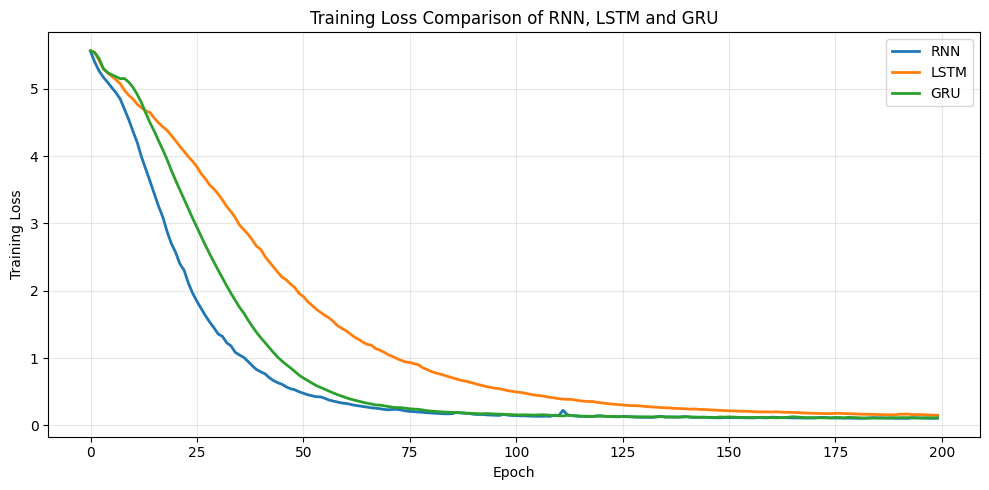

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(rnn_history.history['loss'], label='RNN', linewidth=2)
plt.plot(lstm_history.history['loss'], label='LSTM', linewidth=2)
plt.plot(gru_history.history['loss'], label='GRU', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison of RNN, LSTM and GRU")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [28]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [29]:
print("RNN :", generate_text(rnn_model, "romeo and juliet", 10))
print("LSTM:", generate_text(lstm_model, "romeo and juliet", 10))
print("GRU :", generate_text(gru_model, "romeo and juliet", 10))

RNN : romeo and juliet belonged to two rival families in the city of verona
LSTM: romeo and juliet belonged to two rival families in the city of verona
GRU : romeo and juliet belonged to two rival families in the city of verona


In [30]:
seed_phrases = [
    "romeo and juliet",
    "their families",
    "their love",
    "the story"
]

print("=" * 80)
print(f"{'Seed Text':<20} {'Model':<10} Generated Text")
print("=" * 80)

for seed in seed_phrases:
    for model_name, model in [
        ("RNN", rnn_model),
        ("LSTM", lstm_model),
        ("GRU", gru_model)
    ]:
        output = generate_text(model, seed, next_words=10)
        print(f"{seed:<20} {model_name:<10} {output}")

    print("-" * 80)

Seed Text            Model      Generated Text
romeo and juliet     RNN        romeo and juliet belonged to two rival families in the city of verona
romeo and juliet     LSTM       romeo and juliet belonged to two rival families in the city of verona
romeo and juliet     GRU        romeo and juliet belonged to two rival families in the city of verona
--------------------------------------------------------------------------------
their families       RNN        their families fate shocked relatives neighbors leaders and communities pressure of suffering
their families       LSTM       their families carried a long history of conflict anger and misunderstanding emotion
their families       GRU        their families their marriage would finally bring unity between both families and
--------------------------------------------------------------------------------
their love           RNN        their love grew stronger through trust patience honesty and courage by many
their love          

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

In [31]:
print("✓ Task 1: Custom Romeo and Juliet corpus used")
print("✓ Task 2: Embedding dimension increased (32 → 64)")
print("✓ Task 3: Epochs increased (100 → 200)")
print("✓ Task 4: Hidden units increased (64 → 128)")
print("✓ Task 5: Generated text length increased (5 → 10 words)")

✓ Task 1: Custom Romeo and Juliet corpus used
✓ Task 2: Embedding dimension increased (32 → 64)
✓ Task 3: Epochs increased (100 → 200)
✓ Task 4: Hidden units increased (64 → 128)
✓ Task 5: Generated text length increased (5 → 10 words)


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**